<a href="https://colab.research.google.com/github/Divyaniwath02/Machine_vision/blob/main/practical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# Install Required Libraries
# ====================================================

!pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving blur.jpg to blur (1).jpg


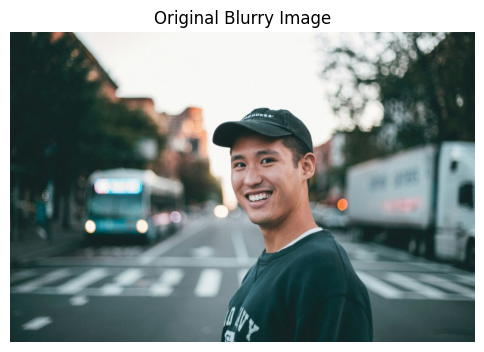

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Blurry Image")
plt.axis("off")
plt.show()

In [ ]:
denoise = cv2.fastNlMeansDenoisingColored(
    img,
    None,
    10,
    10,
    7,
    21
)

In [ ]:
kernel = np.array([
[-1,-1,-1],
[-1, 9,-1],
[-1,-1,-1]
])

sharp = cv2.filter2D(denoise,-1,kernel)

In [ ]:
lab = cv2.cvtColor(sharp, cv2.COLOR_BGR2LAB)

l,a,b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

cl = clahe.apply(l)

enhanced = cv2.merge((cl,a,b))

result = cv2.cvtColor(
    enhanced,
    cv2.COLOR_LAB2RGB
)

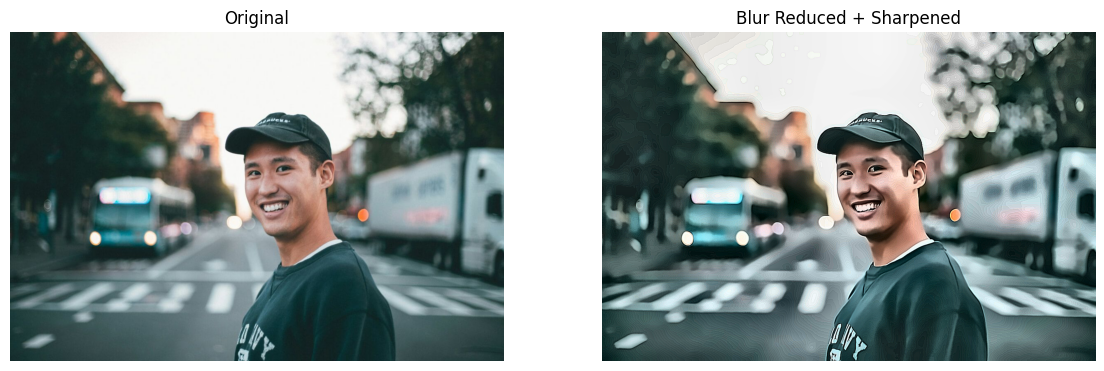

In [ ]:
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Blur Reduced + Sharpened")

plt.axis("off")

plt.show()